**Author:** Brendan OConnell 

**Date:** April 2026  

**Purpose:** Non-Linear EDA via UMAP on NFI particle dataset (follow up to `particle_eda.ipynb`)

**Key decisions:**  

* Stratify sample data using `binary["label"]` to maintain class balance & for compute resource
* UMAP vs PCA comparison suggests strong non-linear relationships.
* Ambiguous particles cannot confidently be classified as either GSR or Non-GSR.
* Non-GSR barium particle classes will likely be high contributors to false positives.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import umap

# Viz
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import glasbey  # for colorblind palette
import seaborn as sns  # for colorblind palette

# KNN metric evaluation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
parquet_path = Path("../../data/processed/particle_labeled.parquet")
nfi_df = pd.read_parquet(parquet_path)
nfi_df.shape

(2801667, 95)

In [3]:
# Isolate element columns
element_cols = list(nfi_df.loc[:, "ac":"zr"].columns)

In [4]:
# Use non-zero rates from particle_eda.ipynb to filter out non-informative elements
nonzero_rates = (nfi_df[element_cols] > 0).mean().sort_values(ascending=False)
informative_cols = sorted(nonzero_rates[nonzero_rates > 0.01].index.tolist())
len(informative_cols)

27

**Binary subset**

Stratify the binary subset to maintain class balance and save compute resources

In [5]:
# Binary filter
binary = nfi_df[nfi_df["label"].isin(["GSR", "Non_GSR"])]

# Sample 10% to save my laptop  :)
sample, _ = train_test_split(
    binary,
    train_size=0.1,
    stratify=binary["label"],
    random_state=42,
)

f"Sample size: {len(sample):,}"

'Sample size: 229,498'

In [6]:
X_sample = sample[informative_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# UMAP

**Default hyperparameters**

n_neighbors=15  (balance local vs. global structure)

min_dist=0.1    (tightness of clusters)

n_components=2  (2D viz)

metric="euclidean"  (default measuring technique for continuous data)

random_state=42,  (reproducibility: keep at 42 for comparing w/ different params & ambiguous class)

low_memory=True (help w/ compute resources)

n_jobs=1        (required value when using random state)

In [7]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
    low_memory=True,
    n_jobs=1,
)
X_umap = reducer.fit_transform(X_scaled)

### Figure 8

2 UMAP plots:
- GSR vs. Non-GSR
- by Particle class

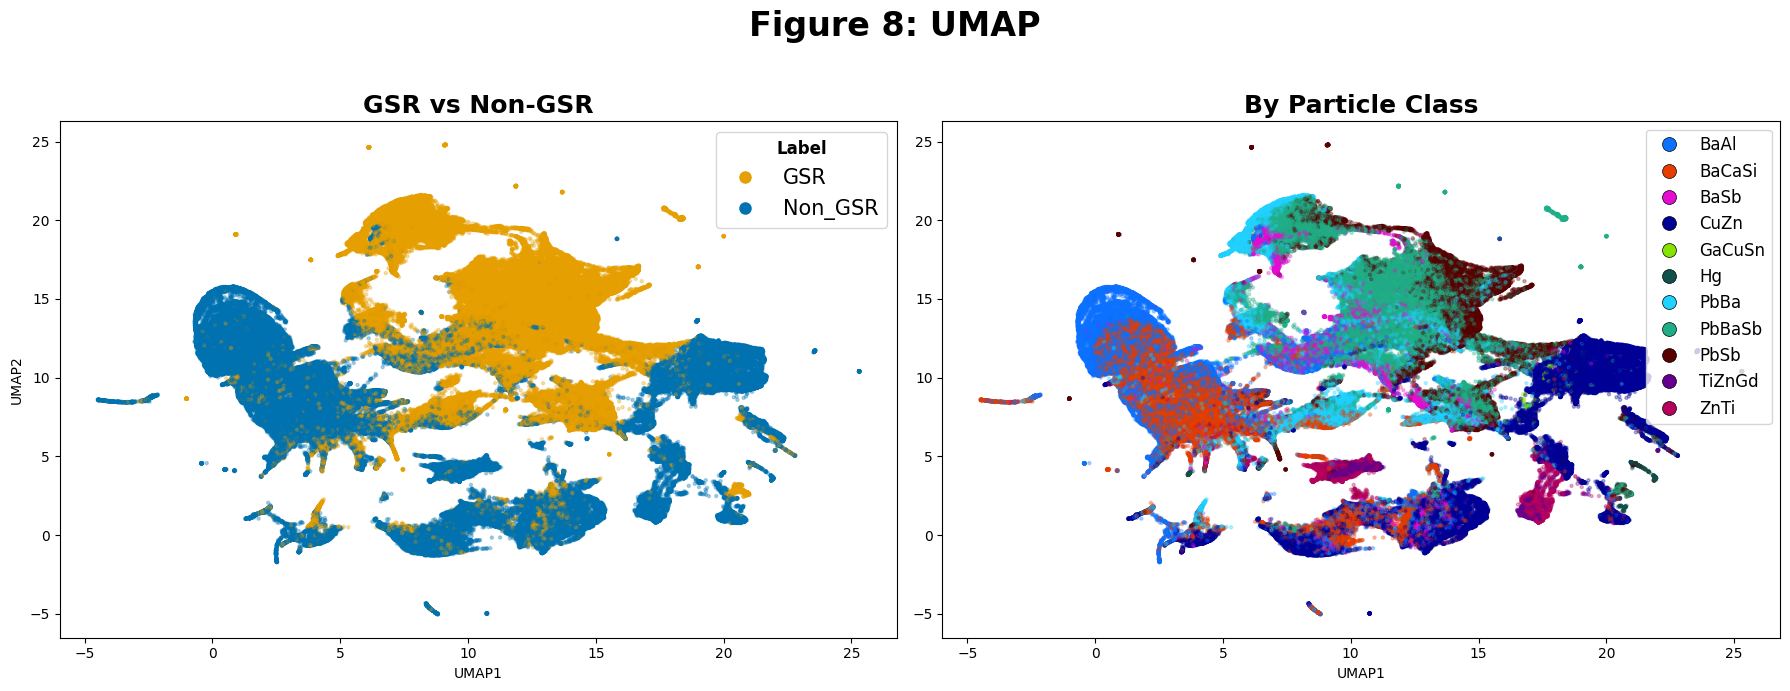

In [ ]:
# Plot the UMAP results (2 plots) colored by: 1) binary label; 2) particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample["final_class"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorblind friendly colors
colors = (
    sample["label"]
    .map({"GSR": "#E69F00", "Non_GSR": "#0072B2"})  # orange  # blue
    .values
)
# palette = sns.color_palette("colorblind", n_colors=len(le.classes_))
palette = glasbey.create_palette(palette_size=len(le.classes_), colorblind_safe=True)
point_colors = [palette[i] for i in class_encoded]

# scatter plot for binary labels
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.3, s=5)
axes[0].set_title("GSR vs Non-GSR", fontsize=18, fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# legend for binary labels
handles = [
    mlines.Line2D(
        [], [], color=colors[1], marker="o", linestyle="None", markersize=8, label="GSR"
    ),
    mlines.Line2D(
        [],
        [],
        color=colors[0],
        marker="o",
        linestyle="None",
        markersize=8,
        label="Non_GSR",
    ),
]
bin_legend = axes[0].legend(handles=handles, loc="upper right", fontsize=15)
bin_legend.set_title("Label", prop={"size": 12, "weight": "bold"})
title = bin_legend.get_title()

# scatter plot for particle classes
scatter = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=point_colors, alpha=0.3, s=5)
axes[1].set_title("By Particle Class", fontsize=18, fontweight="bold")
axes[1].set_xlabel("UMAP1")

# custom legend for particle classes
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for i, cls in enumerate(sorted(le.classes_))
]
axes[1].legend(handles=handles, loc="upper right", fontsize=12, ncol=1, markerscale=1)

fig.suptitle("Figure 8: UMAP", fontsize=24, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("outputs/umap__gsr_vs_non_gsr.png", dpi=150, bbox_inches="tight")
plt.show()

# Amiguous particle UMAP analysis

In [9]:
# Get ambiguous class
ambiguous = nfi_df[nfi_df["label"] == "Ambiguous"]
ambiguous["final_class"].value_counts()

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64

**Sample 10% of ambiguous class**

In [10]:
amb_sample, _ = train_test_split(ambiguous, train_size=0.1, random_state=42)

X_amb = scaler.transform(amb_sample[informative_cols].fillna(0).values)
X_amb_umap = reducer.transform(X_amb)

**kNN classification accuracy**

Tests whether neighbors in the embedding share labels

In [11]:
X_umap_np = np.array(X_umap)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample["label"].values)
knn_umap = cross_val_score(knn, X_umap_np, labels, cv=5, scoring="accuracy").mean()

f"kNN classification accuracy: {knn_umap * 100:.1f}%"

'kNN classification accuracy: 93.8%'

### Figure 9

**Ambiguous particles UMAP overlay viz**

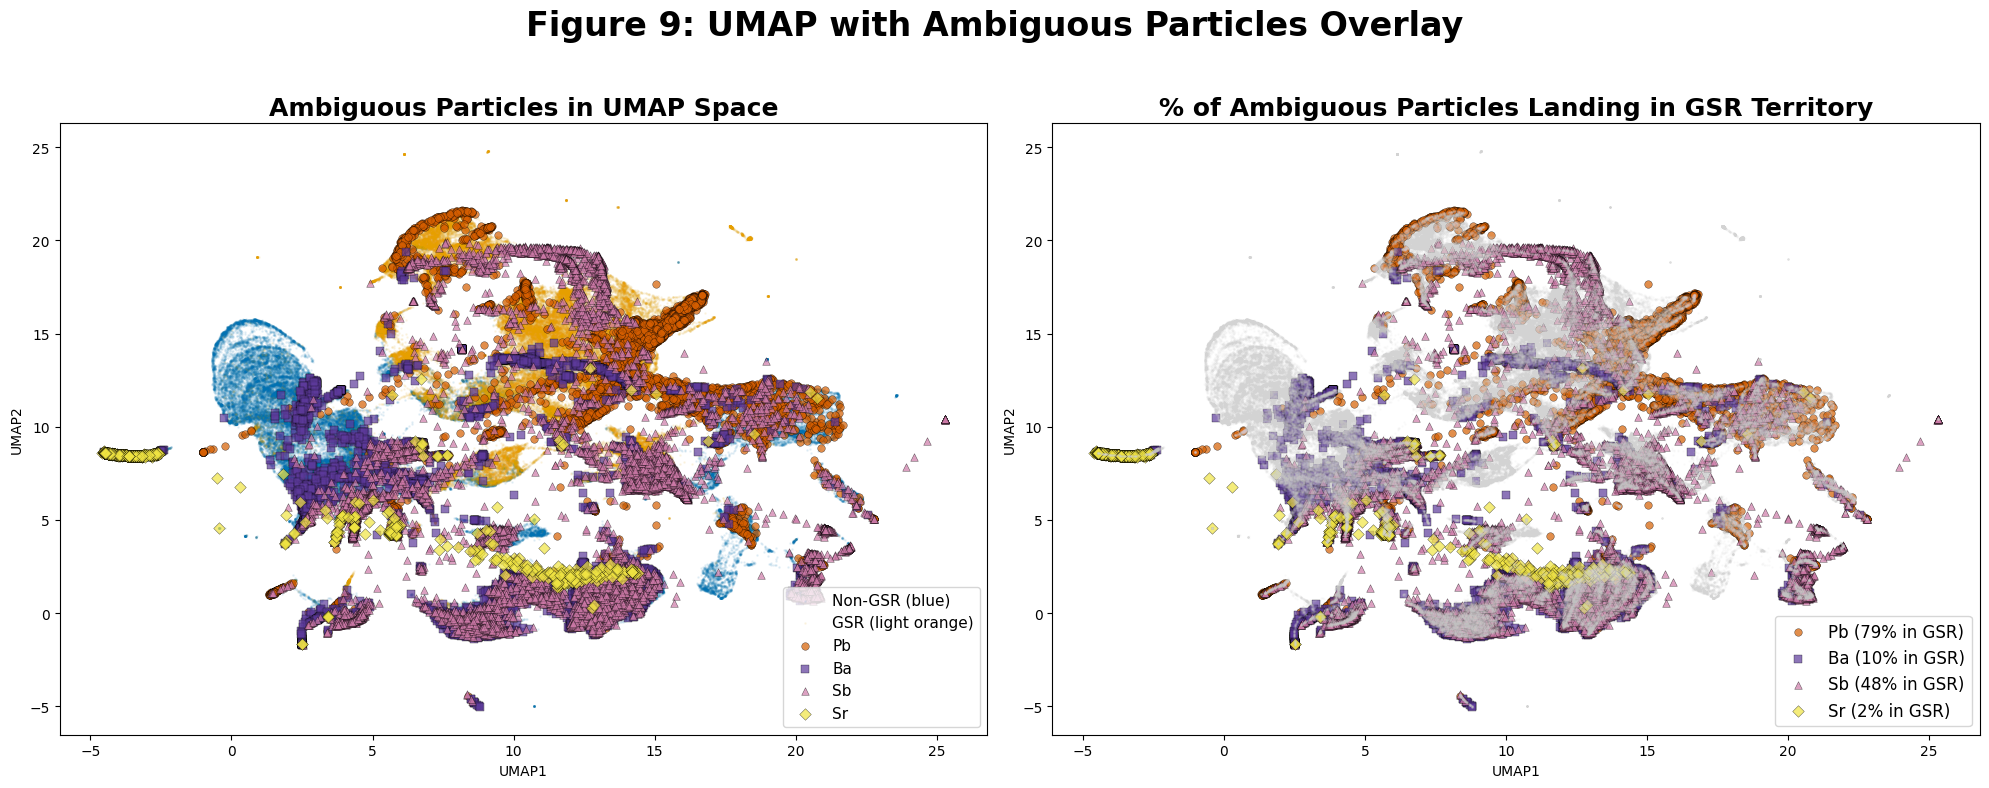

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left panel: ambiguous overlaid on binary
gsr_mask = sample["label"] == "GSR"
nongsr_mask = sample["label"] == "Non_GSR"

# non-gsr
axes[0].scatter(
    X_umap[nongsr_mask, 0],
    X_umap[nongsr_mask, 1],
    c="#0072B2",
    alpha=0.07,
    s=1,
    label="Non-GSR (blue)",
)
# gsr
axes[0].scatter(
    X_umap[gsr_mask, 0],
    X_umap[gsr_mask, 1],
    c="#E69F00",
    alpha=0.07,
    s=1,
    label="GSR (light orange)",
)
# ambiguous (colorblind friendly)
amb_styles = [
    ("Pb", "#D55E00", "o", 30),  # vermillion circles
    ("Ba", "#5D3A9B", "s", 30),  # violet squares
    ("Sb", "#CC79A7", "^", 30),  # pink triangles
    ("Sr", "#F0E442", "D", 35),  # yellow diamonds
]

for cls, color, marker, sz in amb_styles:
    mask = amb_sample["final_class"] == cls
    if mask.sum() > 0:
        axes[0].scatter(
            X_amb_umap[mask, 0],
            X_amb_umap[mask, 1],
            c=color,
            s=sz,
            alpha=0.7,
            label=cls,
            marker=marker,
            edgecolors="black",
            linewidths=0.3,
        )

axes[0].legend(fontsize=11, loc="lower right")
axes[0].set_title("Ambiguous Particles in UMAP Space", fontsize=18, fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# Right panel: split by ambiguous class
for i, (cls, color, marker, sz) in enumerate(amb_styles):
    mask = amb_sample["final_class"] == cls
    if mask.sum() == 0:
        continue

    # Count how many land in GSR-heavy vs Non-GSR-heavy regions
    # using a kNN vote from the embedded training
    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_umap, sample["label"].values)
    amb_pred = knn.predict(X_amb_umap[mask])
    gsr_pct = (amb_pred == "GSR").mean() * 100

    axes[1].scatter(
        X_amb_umap[mask, 0],
        X_amb_umap[mask, 1],
        c=color,
        s=sz,
        alpha=0.7,
        marker=marker,
        edgecolors="black",
        linewidths=0.3,
        label=f"{cls} ({gsr_pct:.0f}% in GSR)",
    )

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c="lightgray", alpha=0.05, s=1)
axes[1].legend(fontsize=12, loc="lower right")
axes[1].set_title(
    "% of Ambiguous Particles Landing in GSR Territory", fontsize=18, fontweight="bold"
)
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

fig.suptitle(
    "Figure 9: UMAP with Ambiguous Particles Overlay",
    fontsize=24,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(
#     "outputs/umap__ambiguous_particles_in_umap_space.png", dpi=150, bbox_inches="tight"
# )
plt.show()

**See 99_sandbox for hyperparameter tuning /exploration for UMAP (no significant findings)**